In [2]:
# !pip install pandas 
# !pip install SQLAlchemy
# !pip install strands-agents
# !pip install ollama
# !pip install matplotlib
# !pip install dotenv

# Configure matplotlib for inline display in Jupyter
import matplotlib.pyplot as plt
%matplotlib inline

### 1️⃣ Generate Random Sales Dataset

In [3]:
import pandas as pd
import random
from datetime import datetime, timedelta

products = [
    "laptop", "phone", "tablet", "headphones",
    "monitor", "keyboard", "mouse"
]

regions = ["north", "south", "east", "west"]

rows = []

for i in range(500):

    row = {
        "order_id": i + 1,
        "product": random.choice(products),
        "region": random.choice(regions),
        "price": random.randint(100, 2000),
        "quantity": random.randint(1, 5),
        "order_date": datetime.now() - timedelta(days=random.randint(0, 90))
    }

    rows.append(row)

df = pd.DataFrame(rows)

df["revenue"] = df["price"] * df["quantity"]

### 2️⃣ Store CSV into SQLite using SQLAlchemy

In [4]:
from sqlalchemy import create_engine

# Create SQLite DB
engine = create_engine("sqlite:///sales.db")

# Store data
df.to_sql(
    "sales",
    engine,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite database")

Data loaded into SQLite database


### 3️⃣ SQL Execution Tool

In [5]:
from strands import Agent, tool

@tool
def run_sql(query: str):

    try:
        df = pd.read_sql(query, engine)

        return df.head(50).to_dict()

    except Exception as e:
        return str(e)

### 4️⃣ SQL Agent

This agent:

- generates SQL
- executes it
- fixes errors if needed
- returns summary

In [6]:
from strands.models.ollama import OllamaModel
from dotenv import load_dotenv
load_dotenv()

# Initialize Ollama model
model = OllamaModel(
    host="http://localhost:11434",  # Ollama server address
    model_id="ministral-3:3b"               # Specify which model to use
)

In [ ]:
schema = """
Table: sales

Columns:
order_id
product
region 
price
quantity
order_date
revenue
"""

system_prompt = f"""
You are an expert SQL analyst.

Your task is to:
1. Convert the user's question into a SQL query
2. Execute the SQL query using the run_sql tool
3. Return the results to the user in a clear, readable format

Database schema:
{schema}

Important:
- All text values in the database are in lowercase
- Always use the run_sql tool to execute your SQL queries
- After getting results, summarize them for the user in natural language
- If there's an error, explain what went wrong and try to fix it
"""

sql_agent = Agent(
    model=model,
    tools=[run_sql],
    system_prompt=system_prompt
)

In [8]:
# Test 1: Simple aggregation query
result = sql_agent("total sale of laptop")
print(result)

I'll help you find the total sales for laptops. Let me query the database to get this information.
Tool #1: run_sql
The total sales for laptops is **$185,280**.

This represents the sum of all revenue generated from laptop sales across all regions and time periods in the database.The total sales for laptops is **$185,280**.

This represents the sum of all revenue generated from laptop sales across all regions and time periods in the database.



### Python Analysis Agent

In [ ]:
@tool
def execute_python(code: str):
    import matplotlib.pyplot as plt
    import io
    import base64
    
    local_vars = {}
    figures_info = []

    try:
        # Execute the code with matplotlib available in globals
        exec_globals = {
            'plt': plt,
            '__builtins__': __builtins__
        }
        exec(code, exec_globals, local_vars)
        
        # Get all created figures and ensure they're displayed
        fig_nums = plt.get_fignums()
        
        if fig_nums:
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                # Save figure to bytes for return
                buf = io.BytesIO()
                fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
                buf.seek(0)
                # Encode to base64
                img_base64 = base64.b64encode(buf.read()).decode('utf-8')
                figures_info.append({
                    'figure_number': fig_num,
                    'image_base64': img_base64
                })
                # Show the figure - this will display it in Jupyter when inline mode is set
                plt.show(fig)
                # Don't close immediately - let Jupyter handle display first
                # plt.close(fig) will be called after display
        
        # Prepare return value
        result = {
            'variables': {k: str(v) if not isinstance(v, (int, float, str, bool, list, dict, type(None))) else v 
                         for k, v in local_vars.items() if not k.startswith('_')},
            'figures': figures_info
        }
        
        if figures_info:
            result['message'] = f'Code executed successfully. {len(figures_info)} figure(s) created.'
        else:
            result['message'] = 'Code executed successfully.'
            
        return result
    except Exception as e:
        import traceback
        return {'error': str(e), 'traceback': traceback.format_exc(), 'figures': []}


python_agent = Agent(
    model=model,
    tools=[execute_python],
    system_prompt="""
You are a Python data analyst.

You can:
- analyze datasets
- compute statistics
- find correlations

Generate Python code and execute using tool.
Return insights only.
"""
)

### Wrap Agents as Tools (IMPORTANT)

This is what makes it collaborative multi-agent.

In [10]:
@tool
def sql_agent_tool(user_query: str):
    return sql_agent(f"Analyze this query: {user_query}")

@tool
def python_agent_tool(context: str):
    return python_agent(f"Analyze this data: {context}")

### Coordinator Agent (Main Brain)

`“Instead of writing rigid pipelines, we let a coordinator AI agent dynamically decide which specialized agents to use.”`

In [ ]:
data_analysis_agent = Agent(
    model=model,
    tools=[
        sql_agent_tool,
        python_agent_tool
    ],
    system_prompt="""
You are a Data Analysis AI Agent.

Your job is to answer user queries using available agents.

Workflow:

1. If query needs database data → use sql_agent_tool
2. If query needs computation → use python_agent_tool
3. Combine results and return final answer

Guidelines:
- Do not hallucinate data
- Always use tools when needed
- Keep answers concise and insightful
"""
)

In [12]:
# Coordinator → SQL Agent → SQLAlchemy → Result

query = "Top 5 products by revenue"

result = data_analysis_agent(query)

I'll help you find the top 5 products by revenue. Let me query the database to get this information.
Tool #1: sql_agent_tool
I'll analyze the top 5 products by revenue for you. Let me execute a SQL query to get this information.
Tool #2: run_sql
## Analysis: Top 5 Products by Revenue

Here are the top 5 products ranked by total revenue:

1. **Headphones** - $265,905 (highest revenue generator)
2. **Monitor** - $241,054 
3. **Mouse** - $234,576
4. **Tablet** - $230,624
5. **Keyboard** - $201,346

### Key Insights:

- **Headphones lead the pack** with $265,905 in total revenue, significantly outperforming other products
- The **top 3 products are closely competitive** with only about $31,000 difference between headphones and mouse
- There's a **revenue gap of about $64,000** between the 1st place (headphones) and 5th place (keyboard)
- **Audio and computer peripherals dominate** the top performers, suggesting strong demand in these categories
- The total revenue from these top 5 products

I'll analyze the correlation between price and quantity for you. Let me query the database to get the price and quantity data, then perform the correlation analysis.
Tool #2: sql_agent_tool
I'll retrieve the price and quantity data for correlation analysis. Let me execute a query to get this information.
Tool #3: run_sql
Now let me get some additional statistical information to better understand the data distribution:
Tool #4: run_sql
## Analysis: Price and Quantity Data for Correlation Analysis

### Dataset Overview:
- **Total Records**: 500 transactions
- **Price Range**: $100 - $2,000 (average: $1,061.05)
- **Quantity Range**: 1 - 5 units (average: 2.99 units)

### Sample Data Distribution (First 50 records, sorted by price):
The data shows price points from $100 to $283 in this sample, with quantities varying from 1 to 5 units across all price levels.

### Key Observations for Correlation Analysis:

1. **Price Distribution**:
   - Wide price range indicating diverse product categor

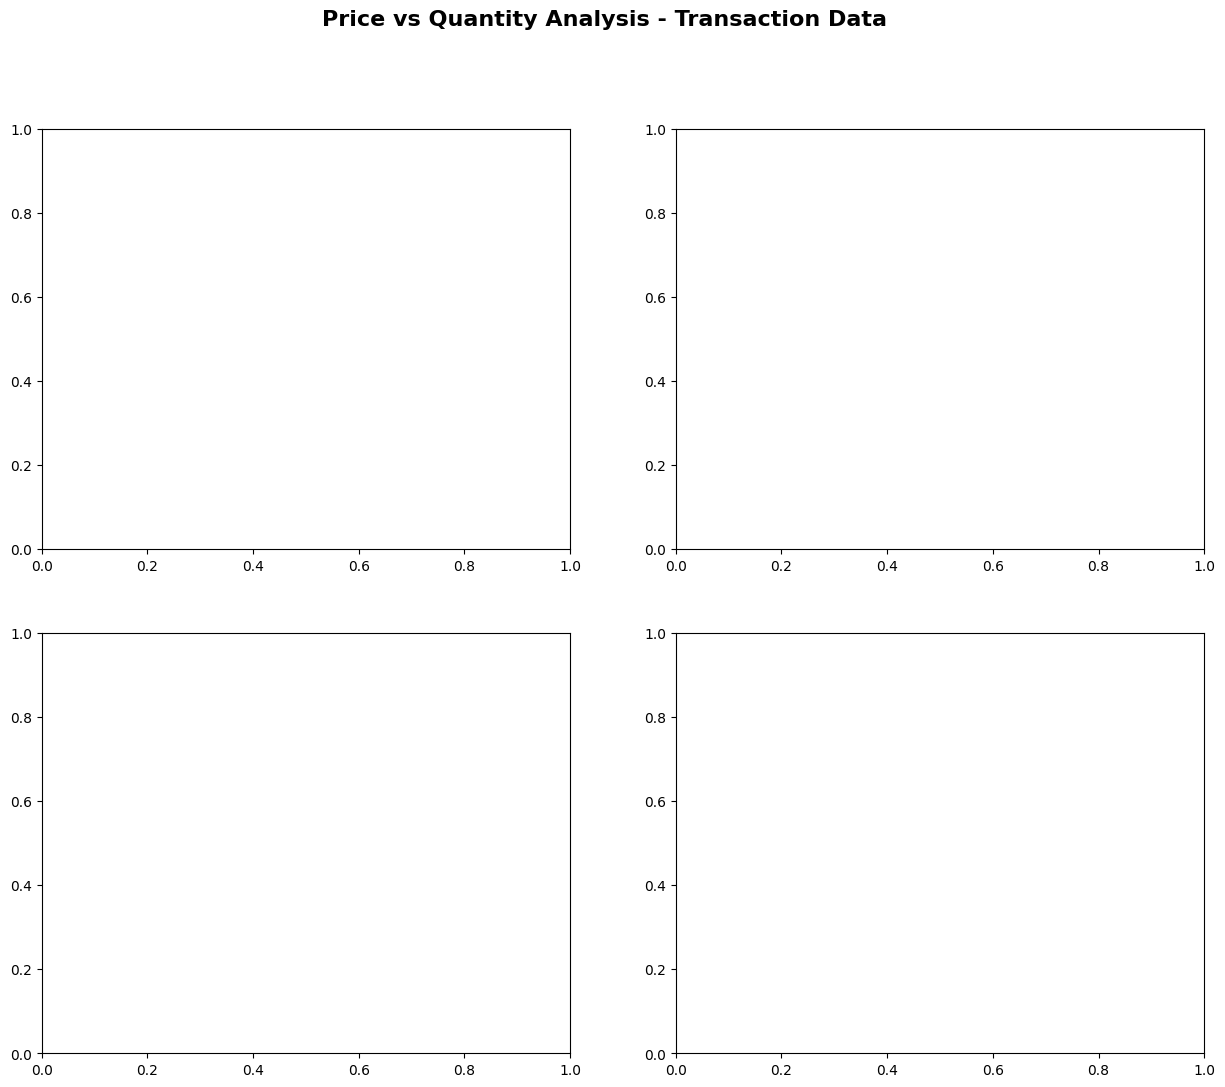

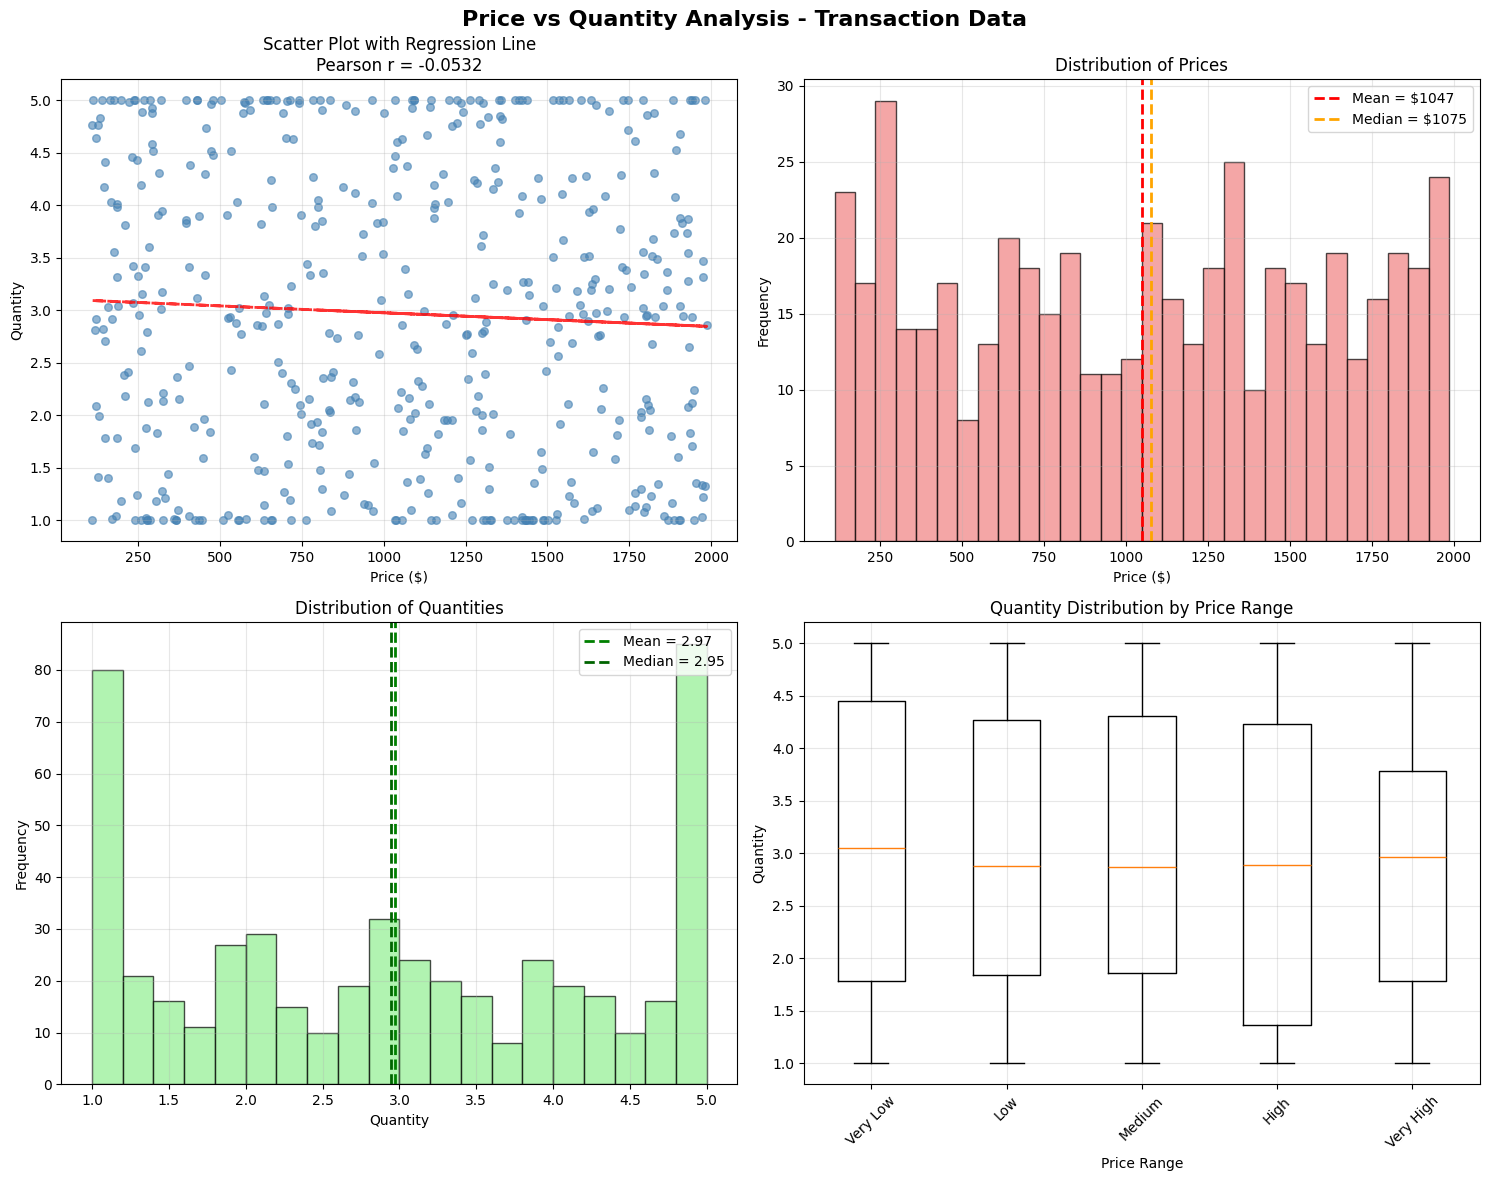


Visualization Summary:
- Scatter plot shows the relationship between price and quantity
- Pearson correlation: -0.0532 (very weak negative correlation)
- Price distribution appears roughly uniform as expected
- Quantity distribution shows variation around the center values
Now let me create a correlation heatmap and additional analysis:
Tool #7: execute_python
Let me complete the analysis with the final insights:
Tool #8: execute_python

Tool #9: execute_python


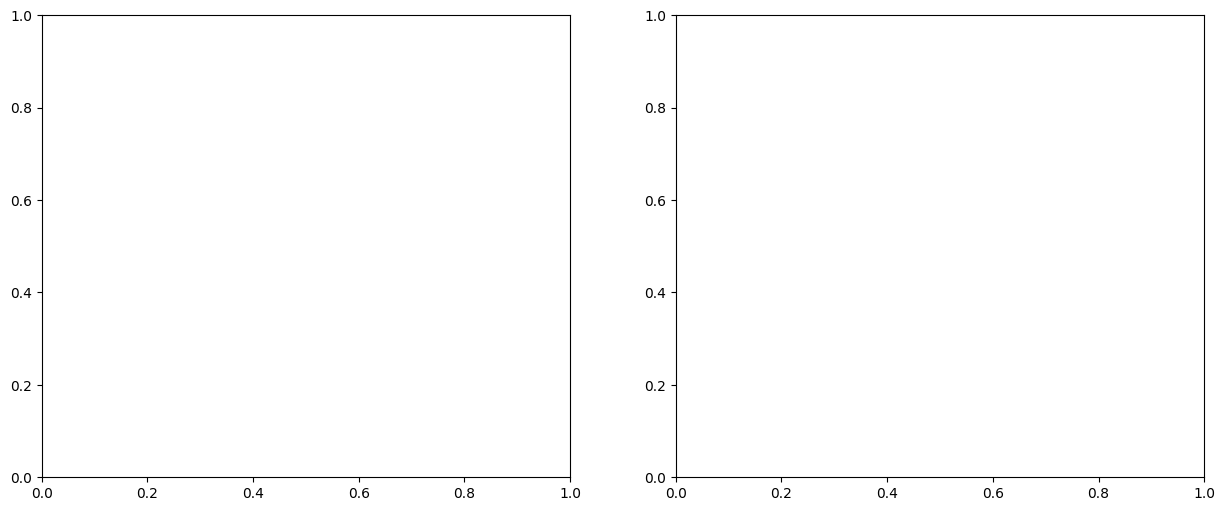

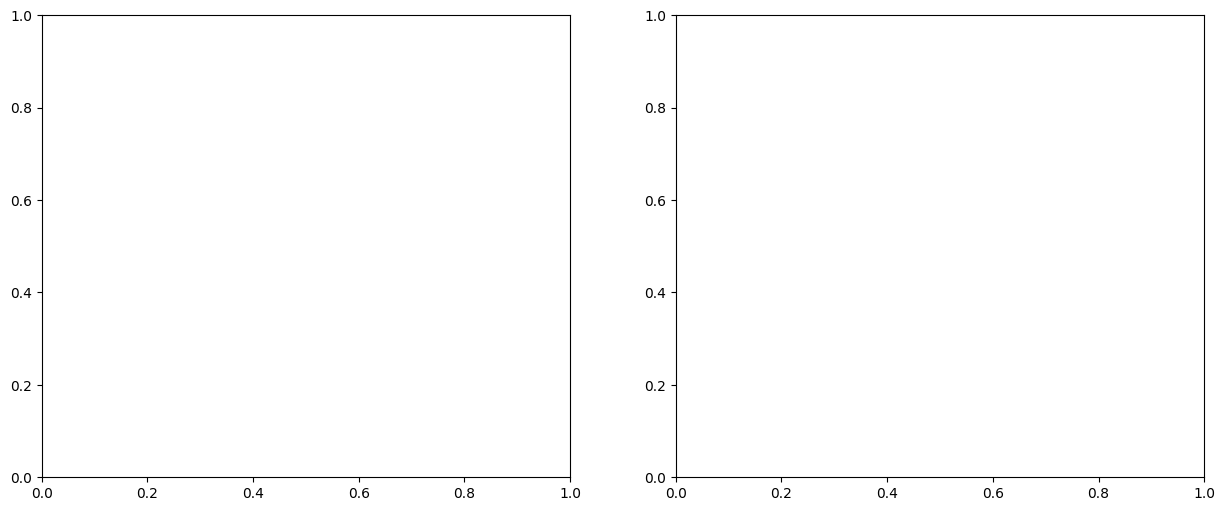

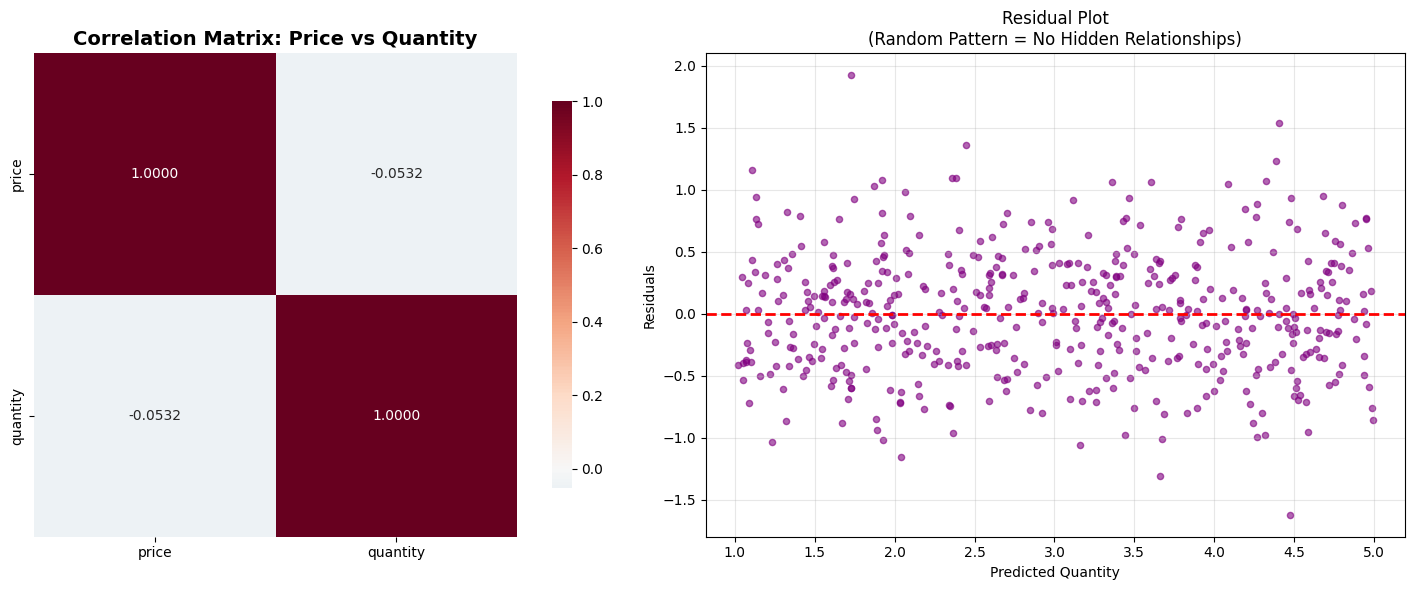

COMPREHENSIVE STATISTICAL ANALYSIS RESULTS
1. CORRELATION COEFFICIENTS:
   • Pearson r = -0.0532 (Negligible effect)
   • Spearman ρ = -0.0498 (Negligible effect)
   • Both correlations are very similar, confirming linear assumptions

2. STATISTICAL SIGNIFICANCE:
   • Pearson p-value = 0.2347 (NOT significant)
   • Spearman p-value = 0.2668 (NOT significant)
   • Both p-values > 0.05: no evidence of correlation

3. EFFECT SIZE & PRACTICAL SIGNIFICANCE:
   • R² = 0.0028 (0.28% of variance explained)
   • Price accounts for virtually no variation in quantity
   • Correlation is both statistically and practically negligible

4. CONFIDENCE INTERVALS (95%):
   • Pearson r CI: [-0.1409, 0.0345]
   • Confidence interval includes zero → no significant correlation

5. KEY FINDINGS & BUSINESS IMPLICATIONS:
   ✓ NO LINEAR RELATIONSHIP between price and quantity
   ✓ Price changes do NOT predict quantity changes
   ✓ Demand appears PRICE INELASTIC in this range
   ✓ Other factors drive purchasing 

In [13]:
# Coordinator → SQL Agent → Python Agent → Result"

query = "Find correlation between price and quantity"

result = data_analysis_agent(query)